In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 


In [17]:
pd.set_option('display.max_columns', None)

In [18]:
sns.set_style('whitegrid')

In [19]:
df =pd.read_csv("german_credit_data.csv")

In [21]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [20]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [11]:
df.shape

(1000, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [13]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df["Job"].unique()

array([2, 1, 3, 0])

In [15]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df = df.dropna().reset_index(drop=True)

In [20]:
df


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [21]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

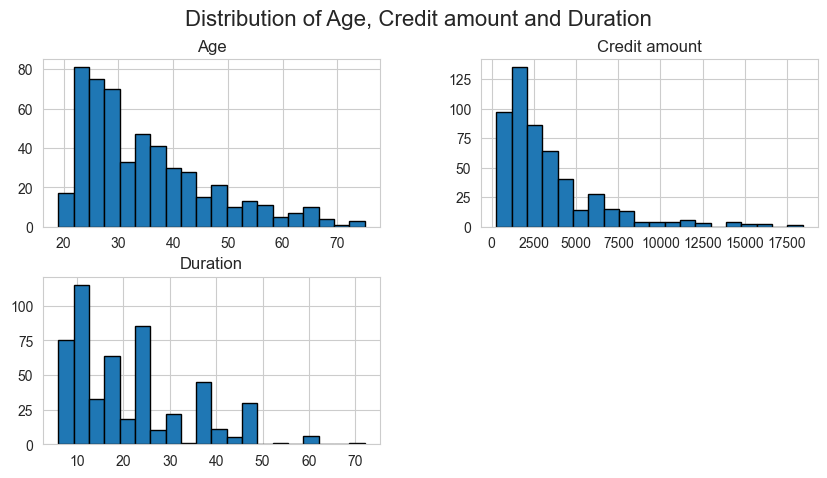

In [24]:
df[["Age","Credit amount", "Duration"]].hist(figsize=(10, 5), bins=20, edgecolor="black")
plt.suptitle("Distribution of Age, Credit amount and Duration", fontsize=16)
plt.show()

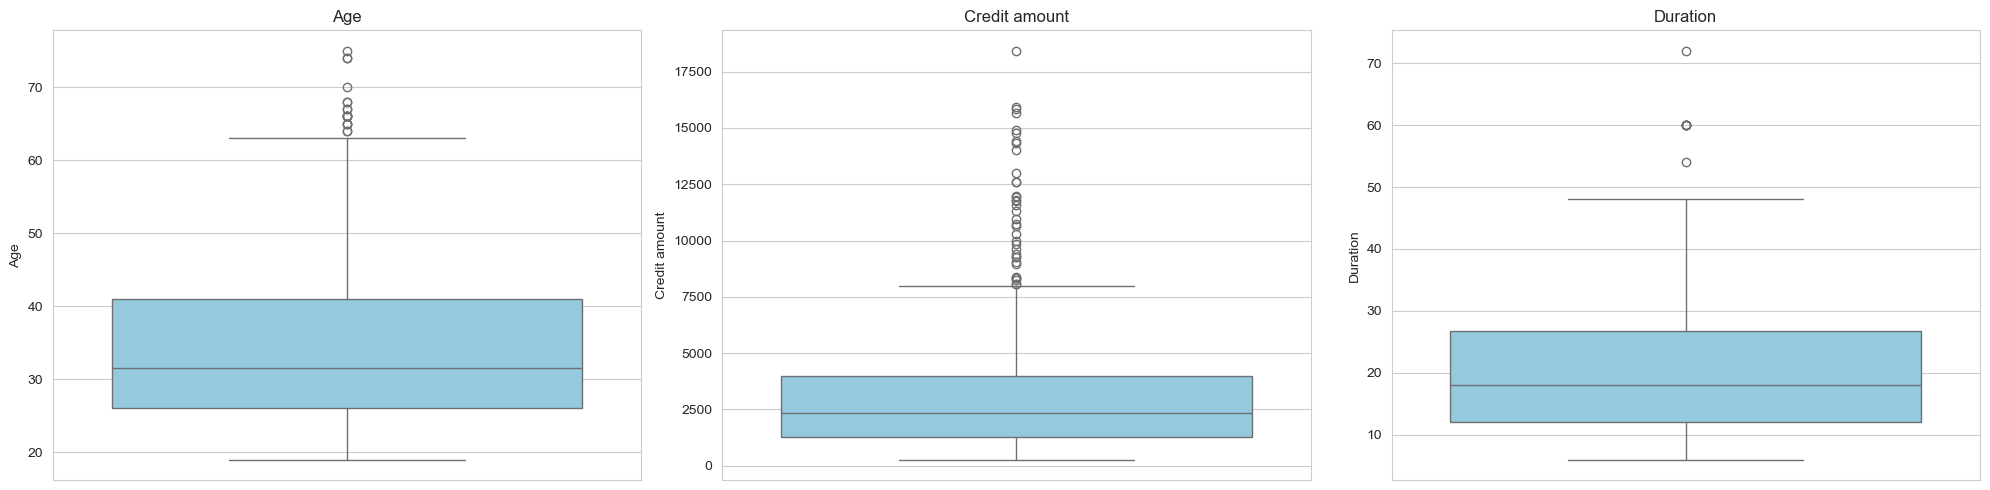

In [27]:
plt.figure(figsize=(20, 5))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [28]:
df.query("Duration >= 60 ")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,29,63,male,2,own,little,little,6836,60,business,bad
176,332,24,female,3,own,moderate,moderate,7408,60,car,bad
199,374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,714,27,male,3,own,little,moderate,14027,60,car,bad
489,938,42,male,2,free,little,moderate,6288,60,education,bad
507,973,36,male,2,rent,little,little,7297,60,business,bad


In [29]:
categorical_cols= ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

C:\Users\User\AppData\Local\Temp\ipykernel_17100\2541918362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col, palette = "Set2",order=df[col].value_counts().index)
C:\Users\User\AppData\Local\Temp\ipykernel_17100\2541918362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col, palette = "Set2",order=df[col].value_counts().index)
C:\Users\User\AppData\Local\Temp\ipykernel_17100\2541918362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x= col, palette = "Set2",order=df[col].value_counts().in

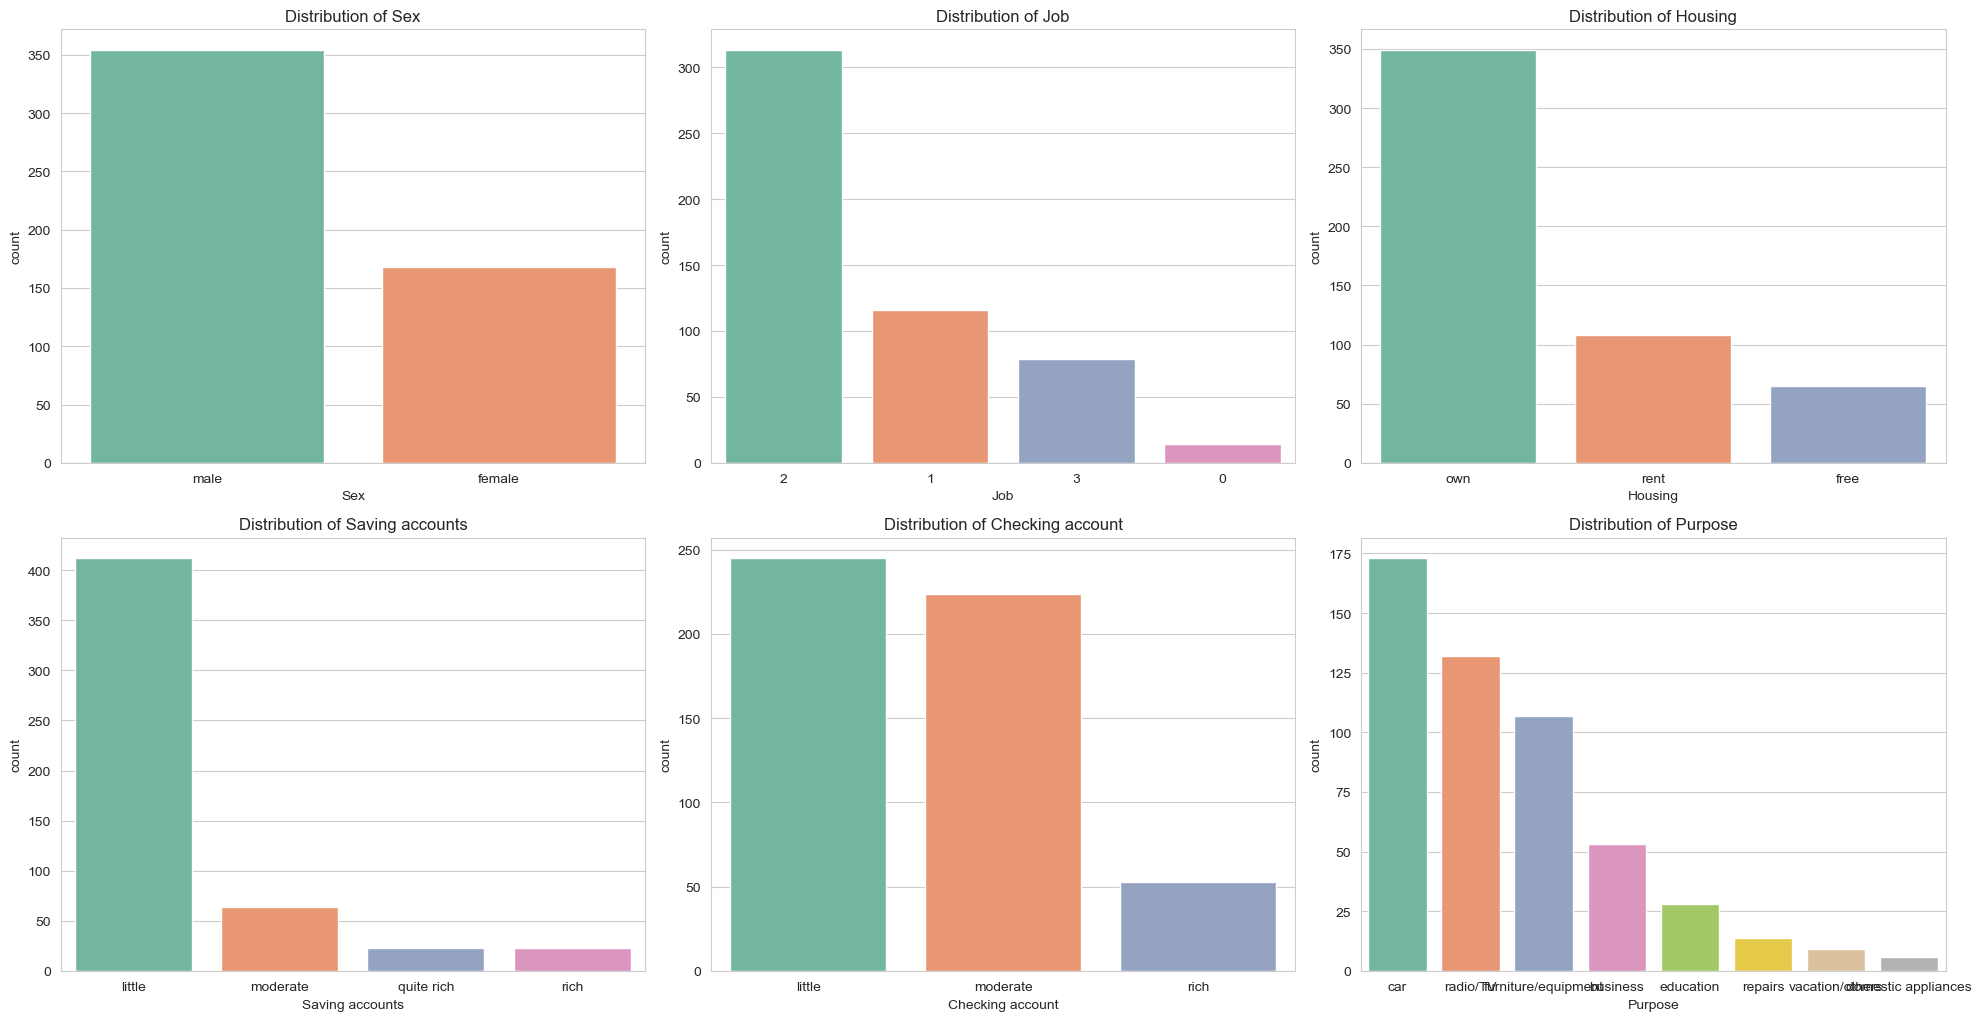

In [33]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x= col, palette = "Set2",order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [25]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()

In [26]:
corr


,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


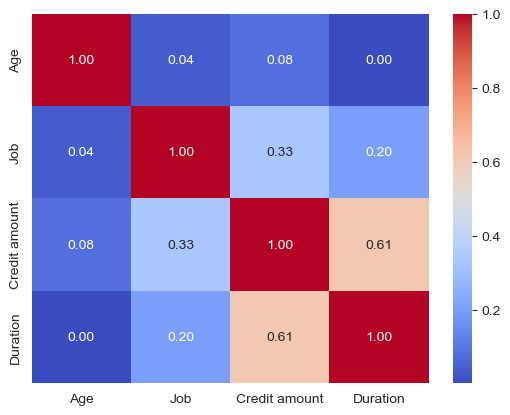

In [37]:
sns.heatmap(corr, annot = True, cmap="coolwarm", fmt=".2f")
plt.show()

In [27]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [30]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [28]:
pd.pivot_table(df, values="Credit amount", index ="Housing",columns ="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


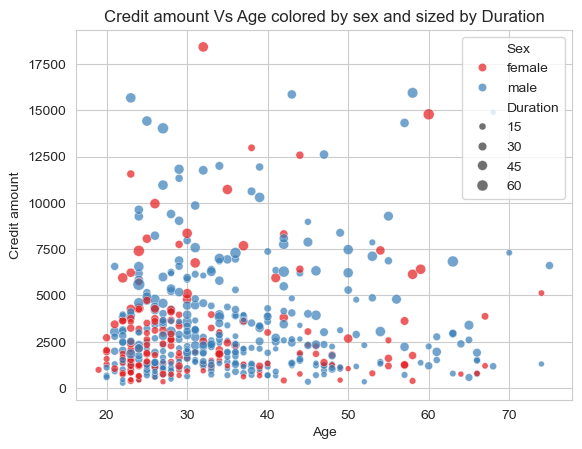

In [43]:
sns.scatterplot(data=df,x="Age",y="Credit amount", hue = "Sex", size="Duration", alpha=0.7,palette="Set1")
plt.title("Credit amount Vs Age colored by sex and sized by Duration")
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17100\1563407377.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")


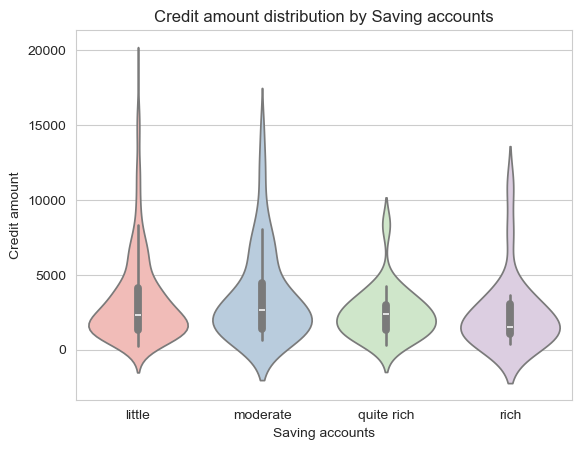

In [44]:
sns.violinplot(data=df, x="Saving accounts", y="Credit amount", palette="Pastel1")
plt.title("Credit amount distribution by Saving accounts")
plt.show()

In [46]:
df["Risk"].value_counts(normalize=True) == 100

Risk
good    False
bad     False
Name: proportion, dtype: bool

C:\Users\User\AppData\Local\Temp\ipykernel_17100\3072115610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df,x="Risk",y=col,palette="Pastel2")
C:\Users\User\AppData\Local\Temp\ipykernel_17100\3072115610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df,x="Risk",y=col,palette="Pastel2")
C:\Users\User\AppData\Local\Temp\ipykernel_17100\3072115610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df,x="Risk",y=col,palette="Pastel2")


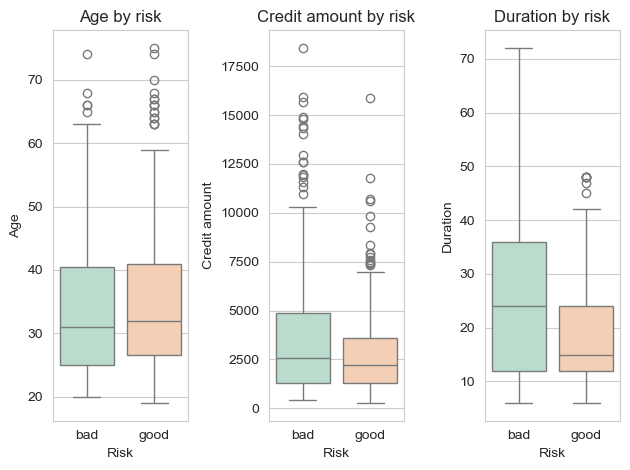

In [48]:
for i, col in enumerate (["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data= df,x="Risk",y=col,palette="Pastel2")
    plt.title(f"{col} by risk")
plt.tight_layout()
plt.show()
    

In [51]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [50]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


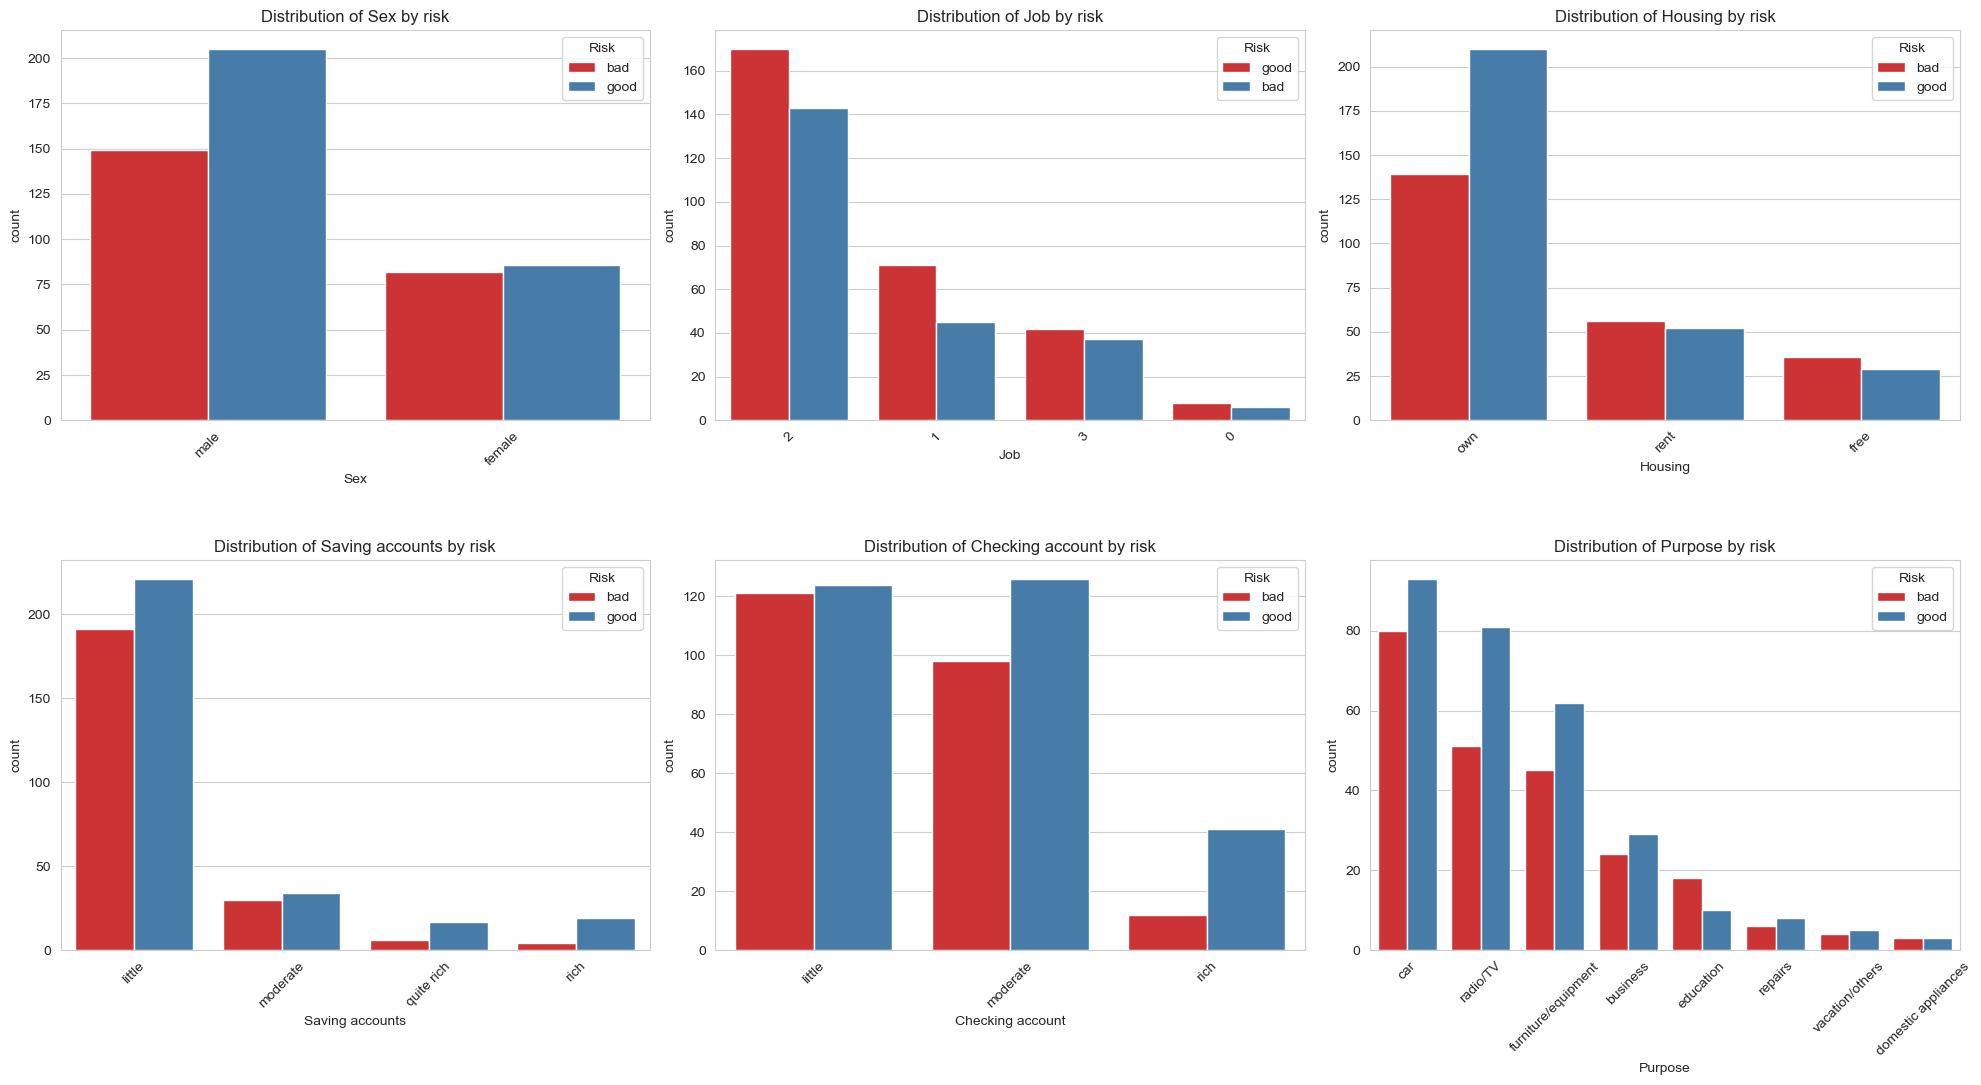

In [54]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x= col, hue="Risk", palette = "Set1",order=df[col].value_counts().index)
    plt.title(f"Distribution of {col} by risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [32]:
features =["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]


In [36]:
target = "Risk"

In [34]:
df_model= df[features + [target]] 

In [60]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [38]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [39]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

C:\Users\User\AppData\Local\Temp\ipykernel_21284\714141096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")


In [63]:
le_dict = {}

In [64]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [65]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f"{col}_label_encoder.pkl")

C:\Users\User\AppData\Local\Temp\ipykernel_17100\3529851451.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col]=le.fit_transform(df_model[col])
C:\Users\User\AppData\Local\Temp\ipykernel_17100\3529851451.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col]=le.fit_transform(df_model[col])
C:\Users\User\AppData\Local\Temp\ipykernel_17100\3529851451.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [66]:
le_target = LabelEncoder()

In [67]:
target

'Risk'

In [70]:
df_model[target]=le_target.fit_transform(df_model[target])  

C:\Users\User\AppData\Local\Temp\ipykernel_17100\1457159301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[target]=le_target.fit_transform(df_model[target])


In [74]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [75]:
joblib.dump(le_target, "target_label_encoder.pkl")

['target_label_encoder.pkl']

In [40]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [1]:
from sklearn.model_selection import train_test_split


In [44]:
x = df_model.drop(target,axis=1)

In [45]:
y= df_model[target]

In [46]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,female,2,own,little,moderate,5951,48
1,45,male,2,free,little,little,7882,42
2,53,male,2,free,little,little,4870,24
3,35,male,3,rent,little,moderate,6948,36
4,28,male,3,own,little,moderate,5234,30
...,...,...,...,...,...,...,...,...
517,48,male,1,own,little,moderate,1743,24
518,30,male,3,own,little,little,3959,36
519,40,male,3,own,little,little,3857,30
520,23,male,2,free,little,little,1845,45


In [81]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [47]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=y,random_state=42)

In [ ]:
X_train.shape

(417, 8)

In [51]:
X_test.shape

(105, 8)

In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [68]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# 1. Identifiez les colonnes catégorielles et numériques
# (Adaptez les noms selon votre DataFrame)
categorical_cols = ['Sex', 'Housing', 'Purpose']  # Colonnes avec du texte
numerical_cols = ['Age', 'Duration', 'Credit amount']  # Colonnes numériques

# 2. Créez un préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Normalisation des variables numériques
        ('cat', OneHotEncoder(drop='first'), categorical_cols)  # One-hot encoding
    ])

# 3. Créez un pipeline complet
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt)  # Votre DecisionTreeClassifier
])

# 4. Adaptez votre fonction train_model
def train_model_with_pipeline(model, param_grid, X_train, y_train, X_test, y_test, 
                              categorical_cols, numerical_cols):
    
    # Préprocesseur
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
        ])
    
    # Pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    
    # Ajustez les paramètres pour GridSearch (ajoutez 'classifier__' devant)
    pipeline_param_grid = {f'classifier__{key}': value for key, value in param_grid.items()}
    
    # GridSearch
    grid = GridSearchCV(pipeline, pipeline_param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_pipeline = grid.best_estimator_
    y_pred = best_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    return best_pipeline, acc, grid.best_params_

In [53]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid ={
    "max_depth": [3, 5, 7,10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [72]:
# Créez vos listes de colonnes
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Colonnes catégorielles à encoder: {categorical_cols}")
print(f"Colonnes numériques: {numerical_cols}")

# Prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),  # Garder telles quelles
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

# Transformer les données
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape après encodage: {X_train_processed.shape}")

# Maintenant votre fonction devrait marcher
best_dt, acc_df, params_dt = train_model(dt, dt_param_grid, X_train_processed, y_train, X_test_processed, y_test)

C:\Users\User\AppData\Local\Temp\ipykernel_21284\2314408363.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


Colonnes catégorielles à encoder: ['Sex', 'Housing', 'Saving accounts', 'Checking account']
Colonnes numériques: ['Age', 'Job', 'Credit amount', 'Duration']
Shape après encodage: (417, 16)
ÉTAPE 1: Préparation des données
y_train original - Type: <class 'pandas.Series'>
y_train après np.array() - Type: <class 'numpy.ndarray'>, dtype: object
Valeurs uniques dans y_train: ['bad' 'good']
Les étiquettes sont-elles numériques? False
🔍 Encodage automatique des étiquettes...
✅ Encodage réussi! Classes: {'bad': np.int64(0), 'good': np.int64(1)}

ÉTAPE 2: Préparation de X
X_train shape: (417, 16), dtype: float64
X_train après conversion float: float64
Valeurs manquantes dans X_train: 0
Valeurs infinies dans X_train: 0

ÉTAPE 3: GridSearchCV
Model: DecisionTreeClassifier
Param grid: {'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}
🚀 Lancement de GridSearchCV...

✅ Résultats:
   Meilleure précision: 0.543
   Meilleurs paramètres: {'max_depth': Non

In [73]:
print(f"Best Decision Tree Accuracy: {acc_df:.4f}")

Best Decision Tree Accuracy: 0.5429


In [74]:
print("Best Decision Tree Parameters:", params_dt)

Best Decision Tree Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [75]:
xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),use_label_encoder=False, eval_metric='logloss')

C:\Users\User\AppData\Local\Temp\ipykernel_21284\3759058225.py:1: RuntimeWarning: invalid value encountered in scalar divide
  xgb = XGBClassifier(random_state=1, scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),use_label_encoder=False, eval_metric='logloss')


In [77]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

In [79]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train_processed, y_train, X_test_processed, y_test)

ÉTAPE 1: Préparation des données
y_train original - Type: <class 'pandas.Series'>
y_train après np.array() - Type: <class 'numpy.ndarray'>, dtype: object
Valeurs uniques dans y_train: ['bad' 'good']
Les étiquettes sont-elles numériques? False
🔍 Encodage automatique des étiquettes...
✅ Encodage réussi! Classes: {'bad': np.int64(0), 'good': np.int64(1)}

ÉTAPE 2: Préparation de X
X_train shape: (417, 16), dtype: float64
X_train après conversion float: float64
Valeurs manquantes dans X_train: 0
Valeurs infinies dans X_train: 0

ÉTAPE 3: GridSearchCV
Model: XGBClassifier
Param grid: {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.8, 1], 'colsample_bytree': [0.8, 1]}
🚀 Lancement de GridSearchCV...


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:23:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Résultats:
   Meilleure précision: 0.438
   Meilleurs paramètres: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [80]:
print("XG accuracy", acc_xgb)

XG accuracy 0.4380952380952381


In [81]:
print("Best Decision Tree Parameters:", params_xgb)

Best Decision Tree Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [86]:
best_dt.predict(X_test_processed)

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0])

In [87]:
joblib.dump(best_dt, "best_decision_tree_model.pkl")

['best_decision_tree_model.pkl']